In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/dataset4'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!git clone https://github.com/microsoft/Swin-Transformer.git


Cloning into 'Swin-Transformer'...
remote: Enumerating objects: 404, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 404 (delta 5), reused 2 (delta 2), pack-reused 393 (from 2)
Receiving objects: 100% (404/404), 1.08 MiB | 18.08 MiB/s, done.
Resolving deltas: 100% (230/230), done.


In [3]:
PRETRAINED: ''
NUM_CLASSES: 4

In [4]:
yaml_content = """
MODEL:
  TYPE: swin
  NAME: swin_tiny_patch4_window7_224
  DROP_PATH_RATE: 0.2
  NUM_CLASSES: 4
  PRETRAINED: ''

DATA:
  BATCH_SIZE: 32
  DATA_PATH: /kaggle/input/dataset4/PlantVillage/train
  IMG_SIZE: 224
  NUM_WORKERS: 4

TRAIN:
  EPOCHS: 100
  BASE_LR: 0.001
  WARMUP_EPOCHS: 5
  WEIGHT_DECAY: 0.05
  OPTIMIZER: adamw
  LR_SCHEDULER: cosine

AUG:
  MIXUP: 0.8
  CUTMIX: 1.0
  AUTO_AUGMENT: rand-m9-mstd0.5-inc1
  COLOR_JITTER: 0.4

SAVE_FREQ: 10
PRINT_FREQ: 50
OUTPUT: /kaggle/working/output
"""


In [ ]:
# 📦 Imports
import os
import numpy as np
import pandas as pd

# 🔍 List all files in the /kaggle/input directory (read-only)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 🧠 Clone the Swin Transformer repo
!git clone https://github.com/microsoft/Swin-Transformer.git /kaggle/working/Swin-Transformer

# 📝 YAML config content (for 4-class corn dataset, no pretrained weights)
yaml_content = """
MODEL:
  TYPE: swin
  NAME: swin_tiny_patch4_window7_224
  DROP_PATH_RATE: 0.2
  NUM_CLASSES: 4
  PRETRAINED: ''

DATA:
  BATCH_SIZE: 32
  DATA_PATH: /kaggle/input/dataset4/PlantVillage/train
  IMG_SIZE: 224
  NUM_WORKERS: 4

TRAIN:
  EPOCHS: 100
  BASE_LR: 0.001
  WARMUP_EPOCHS: 5
  WEIGHT_DECAY: 0.05
  OPTIMIZER: adamw
  LR_SCHEDULER: cosine

AUG:
  MIXUP: 0.8
  CUTMIX: 1.0
  AUTO_AUGMENT: rand-m9-mstd0.5-inc1
  COLOR_JITTER: 0.4

SAVE_FREQ: 10
PRINT_FREQ: 50
OUTPUT: /kaggle/working/output
"""

# 💾 Save YAML file to correct path
config_path = '/kaggle/working/Swin-Transformer/configs/swin_tiny_patch4_window7_224.yaml'
os.makedirs(os.path.dirname(config_path), exist_ok=True)

with open(config_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Config file created at {config_path}")


In [7]:
import os
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from timm.scheduler import CosineLRScheduler
from tqdm import tqdm
import sys
sys.path.append('/kaggle/working/Swin-Transformer') 

# 🧠 Swin model from cloned repo
from models.swin_transformer import SwinTransformer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ✅ Parameters
NUM_CLASSES = 4
BATCH_SIZE = 32
EPOCHS = 100
IMAGE_SIZE = 224
device = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ Data transforms (no segmentation)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# ✅ Datasets
train_dir = '/kaggle/input/dataset4/PlantVillage/train'
test_dir  = "/kaggle/input/dataset4/PlantVillage/test"
val_dir   = "/kaggle/input/dataset4/PlantVillage/val"

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
class_names = train_data.classes
test_data  = datasets.ImageFolder(test_dir, transform=val_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ✅ Swin Transformer (no pretrained)
model = SwinTransformer(img_size=IMAGE_SIZE, patch_size=4, in_chans=3,
                        num_classes=NUM_CLASSES,
                        embed_dims=[96, 192, 384, 768],
                        depths=[2, 2, 6, 2],
                        num_heads=[3, 6, 12, 24],
                        window_size=7,
                        mlp_ratio=4.,
                        qkv_bias=True,
                        drop_path_rate=0.2,
                        ape=False,
                        patch_norm=True)
model.to(device)

# ✅ Optimizer and Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = CosineLRScheduler(optimizer, t_initial=EPOCHS)

# ✅ Loss function
criterion = nn.CrossEntropyLoss()

# ✅ Training loop
def train(model, dataloader, optimizer, scheduler, criterion,epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(dataloader, desc="Training")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

        loop.set_postfix(loss=loss.item(), acc=100. * correct / total)
    
    scheduler.step(epoch)
    return running_loss / len(dataloader), 100. * correct / total

# ✅ Evaluation
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0.0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_total += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return loss_total / len(dataloader), 100. * correct / total

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ✅ Early stopping setup
best_val_acc = 0.0
patience = 5
epochs_no_improve = 0
early_stop = False

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(EPOCHS):
    if early_stop:
        print("\n🛑 Early stopping triggered.")
        break
    
    print(f"\n📅 Epoch {epoch+1:02d}/{EPOCHS}")
    print("=" * 40)

    train_loss, train_acc = train(model, train_loader, optimizer, scheduler, criterion, epoch)
    print(f"✅ Train   | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    test_loss, test_acc = evaluate(model, test_loader)
    print(f"🧪 Test    | Loss: {test_loss:.4f} | Accuracy: {test_acc:.2f}%")
    
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)


    
    # ✅ Early stopping logic (no model saving)
    if test_acc > best_val_acc:
        best_val_acc = test_acc
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"📉 No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        early_stop = False


    # ✅ Important: scheduler step after epoch, NOT inside training loop
    scheduler.step(epoch + 1)

# ✅ Final evaluation on unseen validation set
val_loss, val_acc = evaluate(model, val_loader)
print(f"\n🎯 Final Evaluation on Unseen Validation Set:")
print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

def evaluate_metrics(labels, preds, probs, class_names):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro')
    rec = recall_score(labels, preds, average='macro')
    f1 = f1_score(labels, preds, average='macro')

    df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"],
        "Score": [acc, prec, rec, f1]
    })
    print("\n📋 Performance Metrics Table:\n")
    print(df.to_string(index=False))
    return df

def plot_confusion(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

def plot_roc(labels, probs, class_names):
    n_classes = len(class_names)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")
    
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curve (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

def plot_curves(train_acc_list, test_acc_list, train_loss_list, test_loss_list):
    epochs = range(1, len(train_acc_list)+1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc_list, label="Train Acc")
    plt.plot(epochs, test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy over Epochs")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss_list, label="Train Loss")
    plt.plot(epochs, test_loss_list, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def plot_per_class_metrics(labels, preds, class_names):
    from sklearn.metrics import precision_score, recall_score, f1_score

    # ✅ Per-class metrics
    precision = precision_score(labels, preds, average=None)
    recall = recall_score(labels, preds, average=None)
    f1 = f1_score(labels, preds, average=None)

    x = np.arange(len(class_names))  # class positions
    width = 0.25                     # bar width

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, precision, width, label='Precision')
    plt.bar(x, recall, width, label='Recall')
    plt.bar(x + width, f1, width, label='F1-score')

    plt.xticks(x, class_names, rotation=15)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[Warning] Fused window process have not been installed. Please refer to get_started.md for installation.
Tutel has not been installed. To use Swin-MoE, please install Tutel; otherwise, just ignore this.


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]



📅 Epoch 01/100


Training: 100%|██████████| 72/72 [00:20<00:00,  3.56it/s, acc=70.4, loss=0.613]


...

✅ Train   | Loss: 0.0036 | Accuracy: 99.83%


Evaluating: 100%|██████████| 36/36 [00:03<00:00, 10.32it/s]


🧪 Test    | Loss: 0.0338 | Accuracy: 98.95%
📉 No improvement for 19 epoch(s).


Evaluating: 100%|██████████| 14/14 [00:01<00:00,  7.76it/s]


🎯 Final Evaluation on Unseen Validation Set:
Val Loss: 0.0465 | Val Accuracy: 98.57%



📋 Performance Metrics Table:

           Metric    Score
         Accuracy 0.985680
Precision (Macro) 0.983252
   Recall (Macro) 0.980952
 F1 Score (Macro) 0.982066


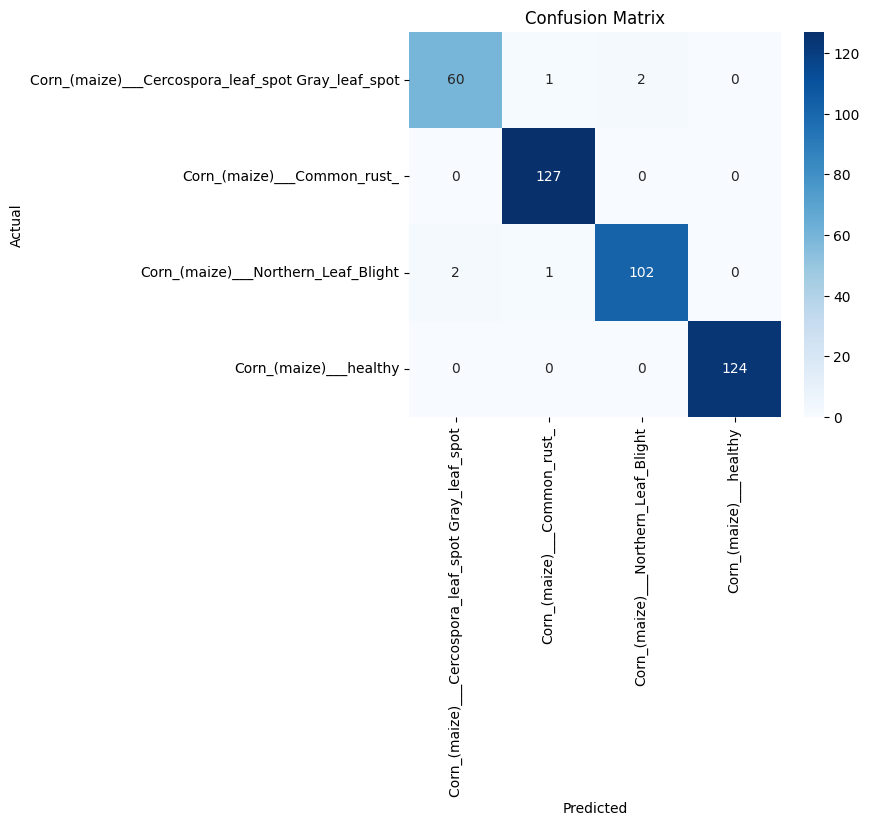

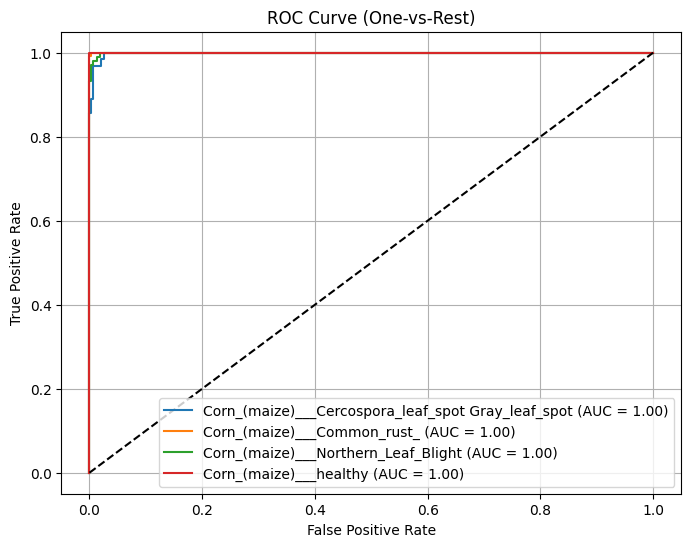

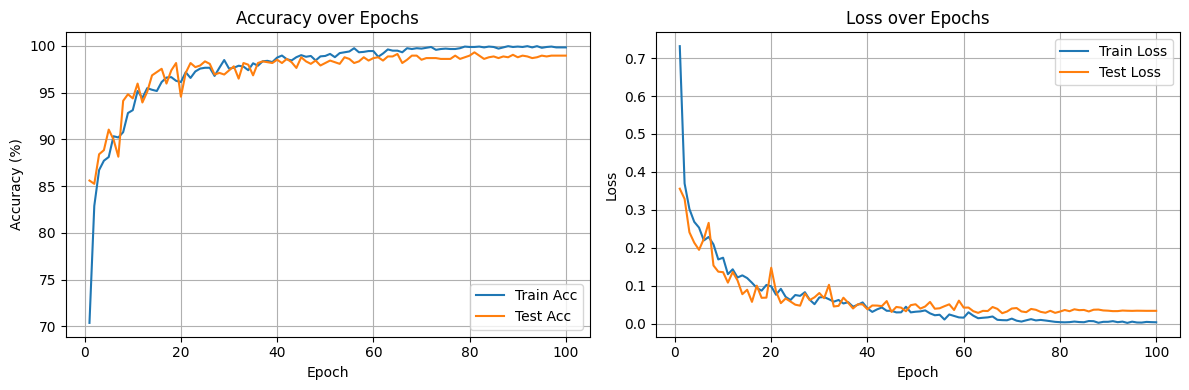

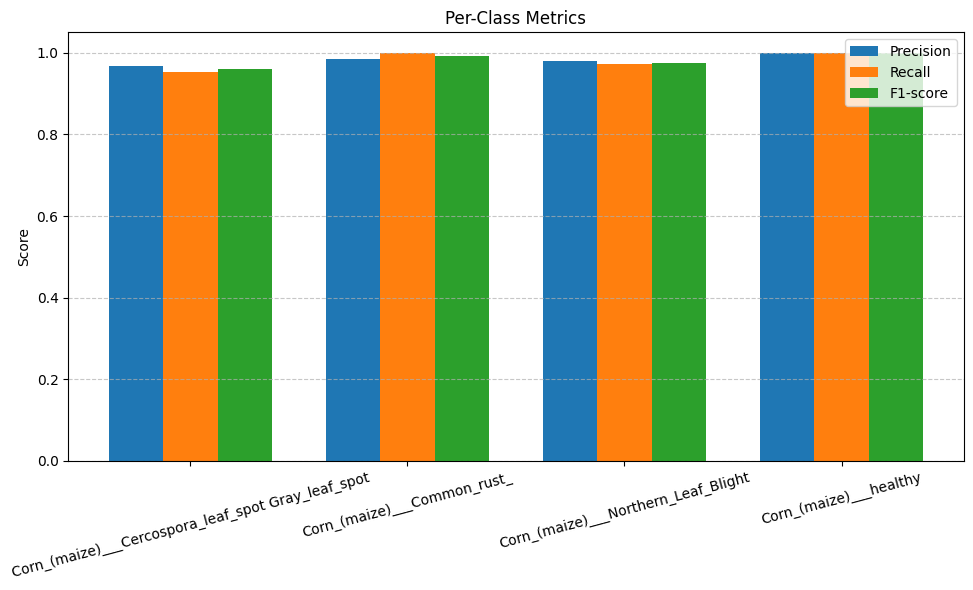

In [8]:
# ✅ Get predictions on validation set
labels, preds, probs = get_predictions(model, val_loader)

# ✅ Show tabular metrics
metrics_df = evaluate_metrics(labels, preds, probs, class_names)

# ✅ Confusion Matrix
plot_confusion(labels, preds, class_names)

# ✅ ROC Curve
plot_roc(labels, probs, class_names)

# ✅ Accuracy and Loss curves
plot_curves(train_acc_list, test_acc_list, train_loss_list, test_loss_list)

# ✅ Per-class Precision / Recall / F1 bar chart
plot_per_class_metrics(labels, preds, class_names)